In [1]:
import numpy
import matplotlib.pyplot as plt

import os


data_path = "data/states_samples/"

data = []

for f in os.listdir(data_path):
    ext = os.path.splitext(f)[-1]
    if "npy" in ext:
        file_name = data_path + str(f)
        
        data_tmp = numpy.load(file_name)

        #print("loading from ", file_name, data_tmp.shape)

        data.append(data_tmp)

data = numpy.array(data)
print("loaded ", data.shape)


loaded  (25, 4096, 64, 64)


In [2]:
data = numpy.reshape(data, (data.shape[0]*data.shape[1], data.shape[2], data.shape[3]))


(array([5.304700e+05, 4.375250e+05, 5.559810e+05, 7.587760e+05,
        1.106080e+06, 3.127582e+06, 1.833900e+04, 3.452400e+04,
        7.471600e+04, 3.956360e+05, 6.864700e+05, 1.522410e+05,
        3.730460e+05, 2.026000e+03, 6.046800e+04, 7.472800e+04]),
 array([ 0.    ,  0.9375,  1.875 ,  2.8125,  3.75  ,  4.6875,  5.625 ,
         6.5625,  7.5   ,  8.4375,  9.375 , 10.3125, 11.25  , 12.1875,
        13.125 , 14.0625, 15.    ]),
 <BarContainer object of 16 artists>)

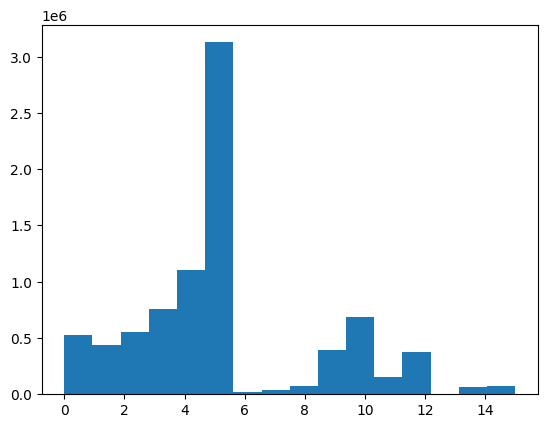

In [3]:

indices = numpy.random.randint(0, data.shape[0], 2048)

data_sample = data[indices]

data_sample = numpy.reshape(data_sample, (data_sample.shape[0]*data_sample.shape[1]*data_sample.shape[2]))

hist, bin_edges = numpy.histogram(data_sample, bins=15)

plt.hist(data_sample, bins=16)

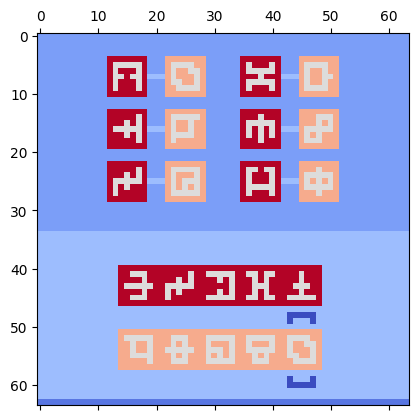

In [4]:
#sample_idx = 0*4096
#sample_idx = 1*4096
sample_idx = 3*4096
#sample_idx = 7*4096
#sample_idx = 10*4096
#sample_idx = 13*4096
#sample_idx = 21*4096

plt.matshow(data[sample_idx], cmap='coolwarm')


64


/var/folders/zm/qgjr306960d8c7tkvjpjkgq80000gn/T/ipykernel_55037/3229172030.py:114: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.matshow(o, cmap='coolwarm')


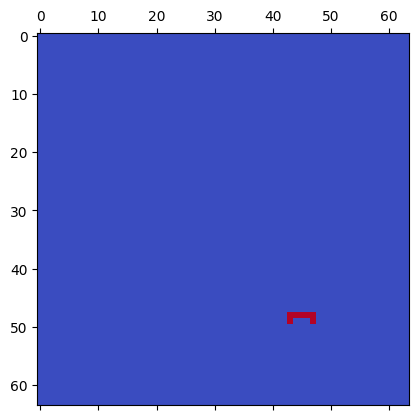

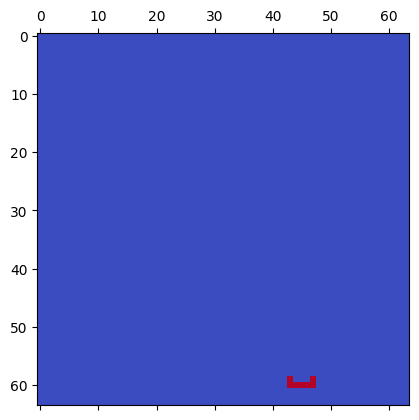

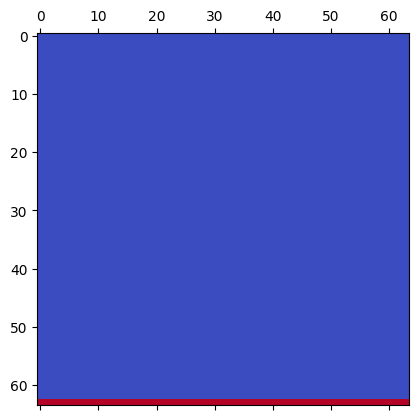

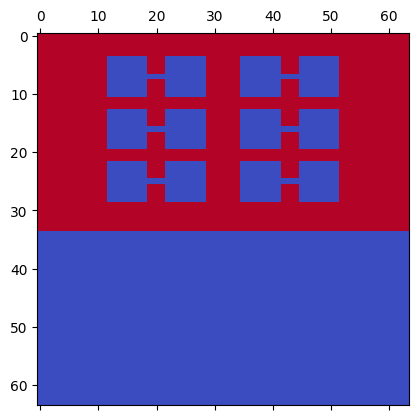

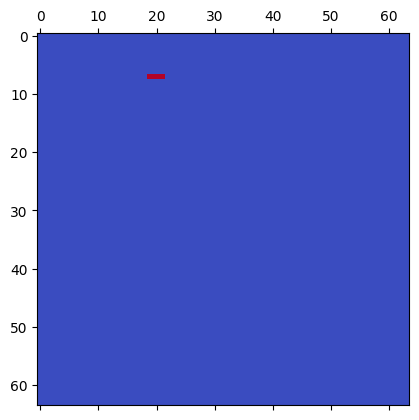

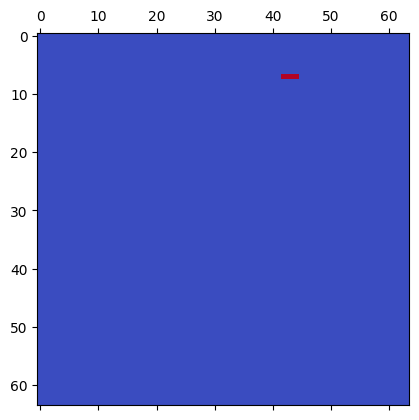

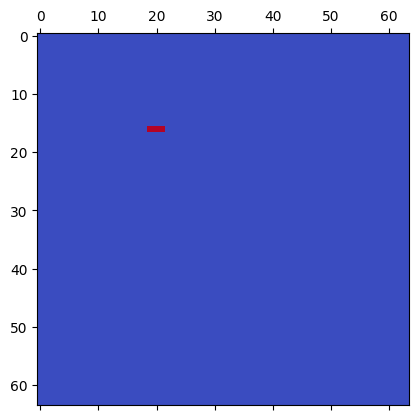

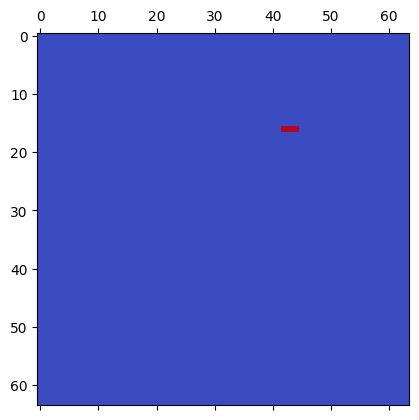

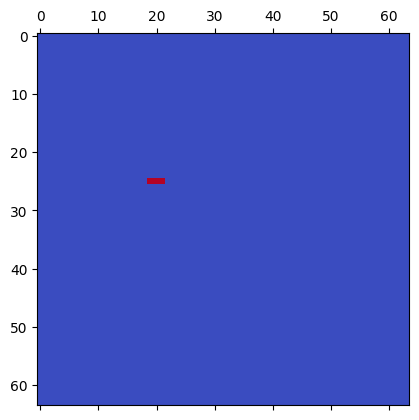

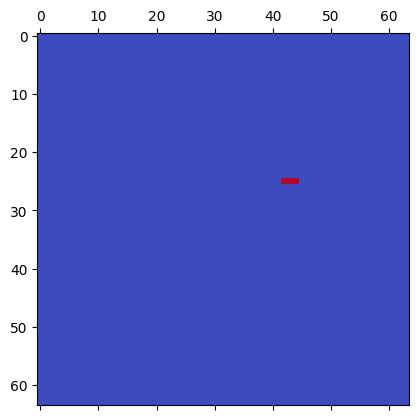

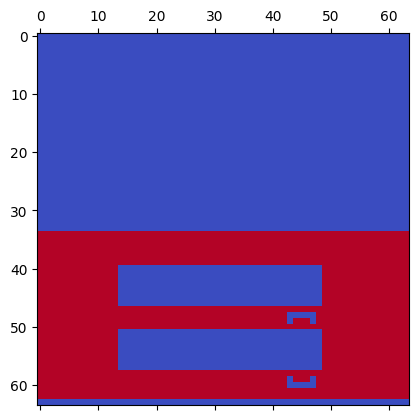

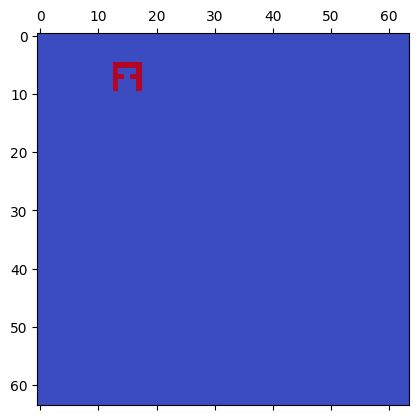

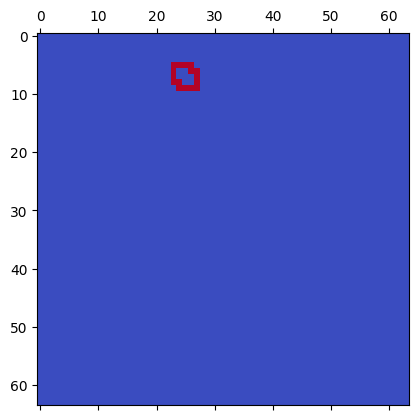

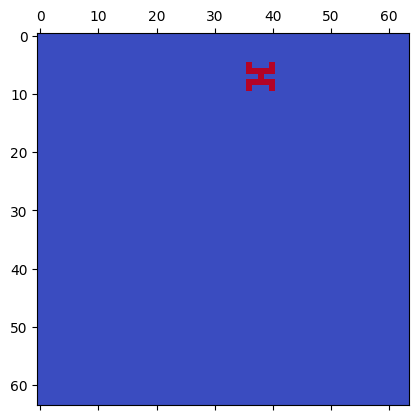

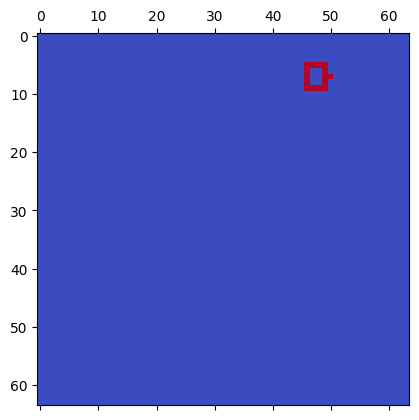

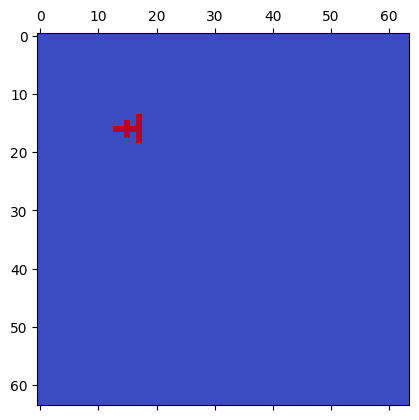

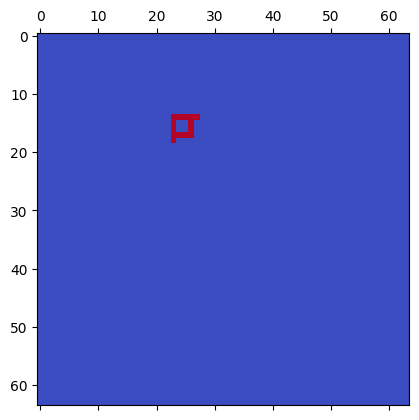

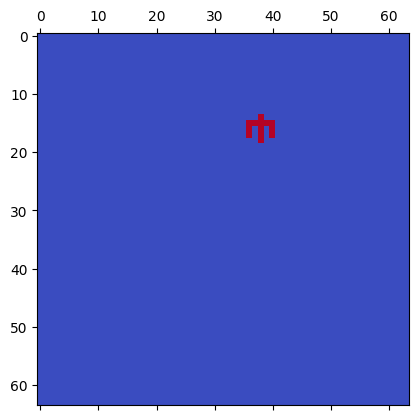

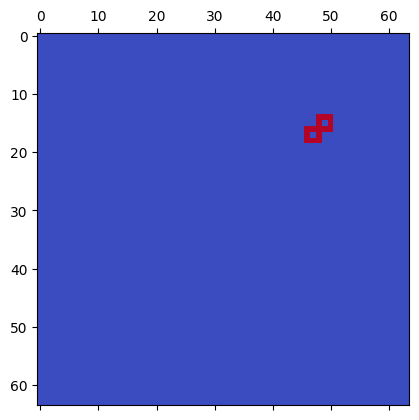

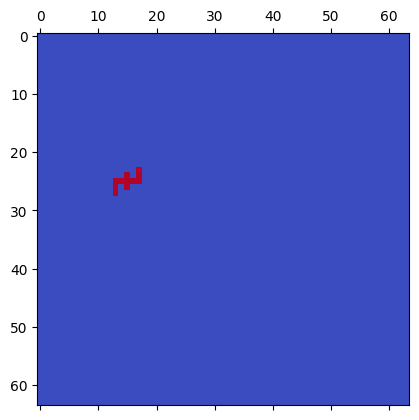

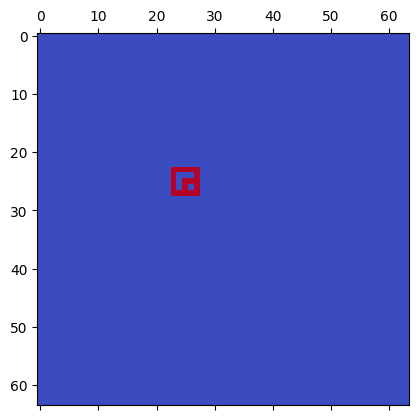

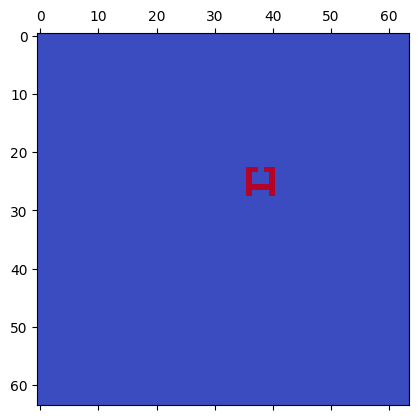

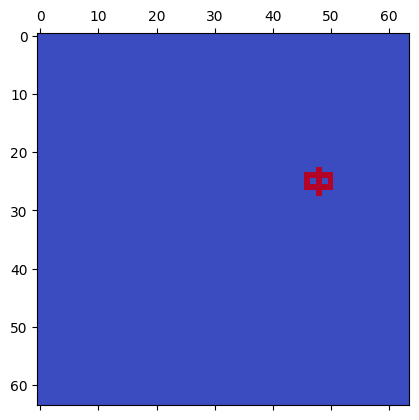

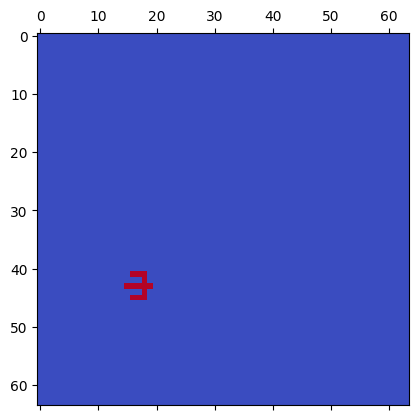

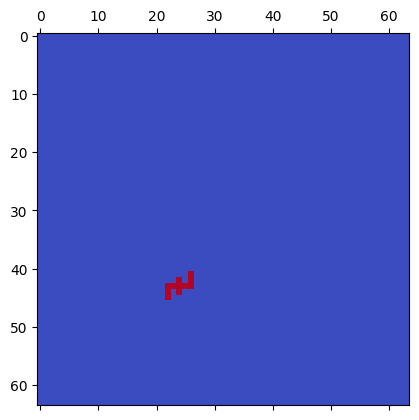

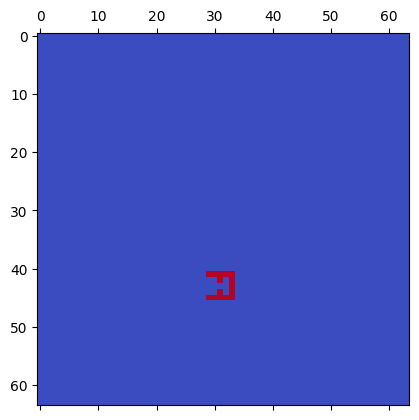

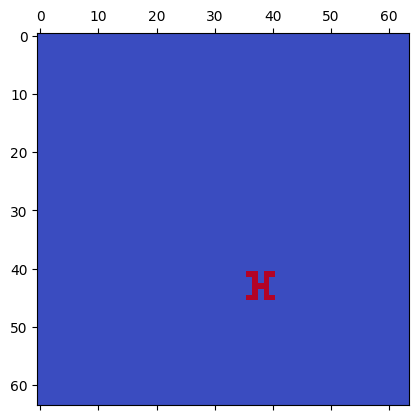

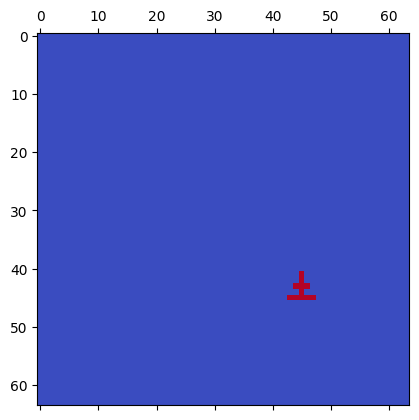

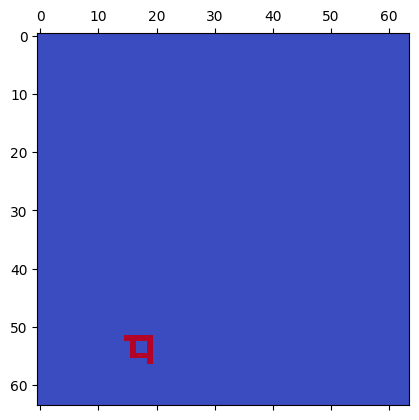

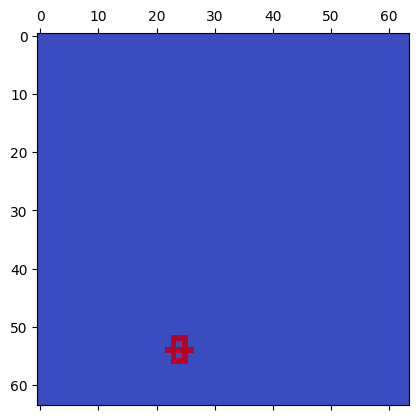

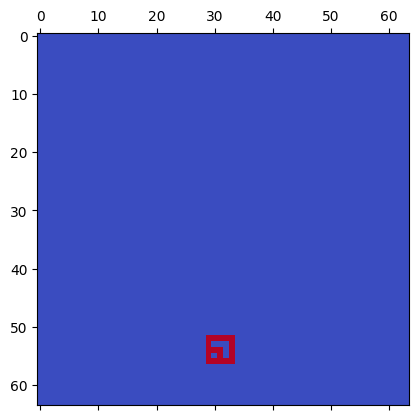

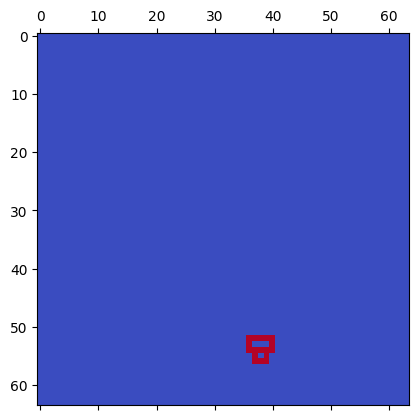

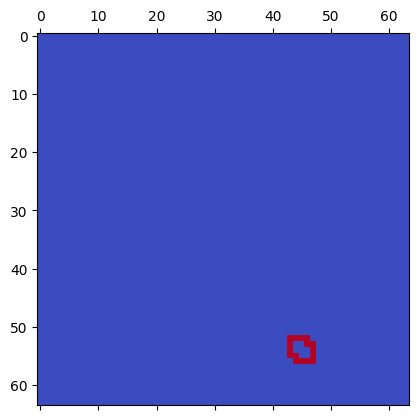

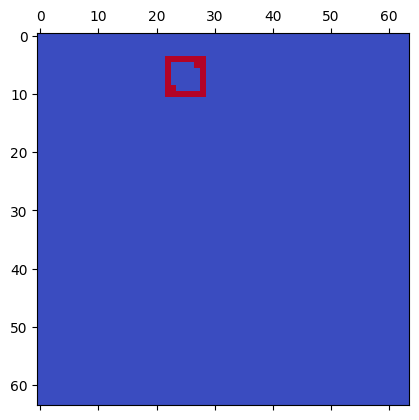

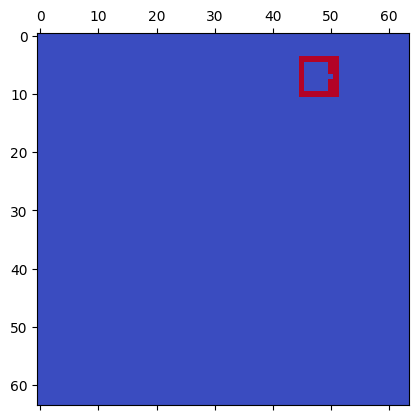

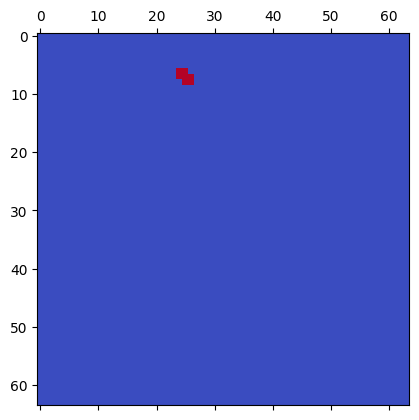

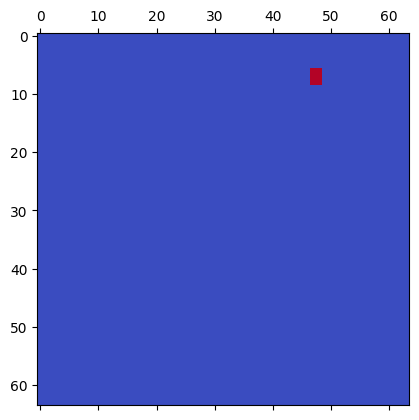

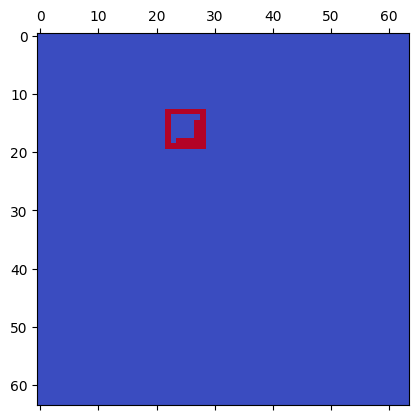

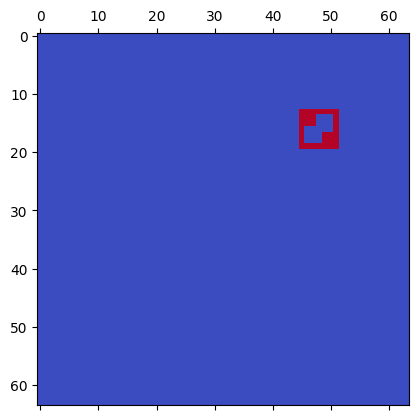

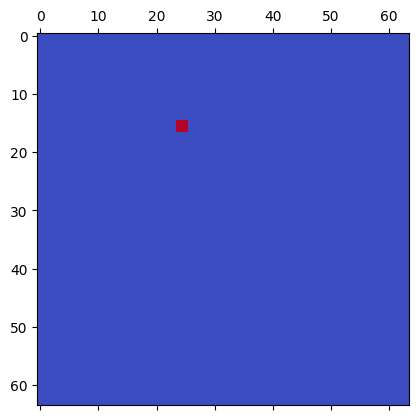

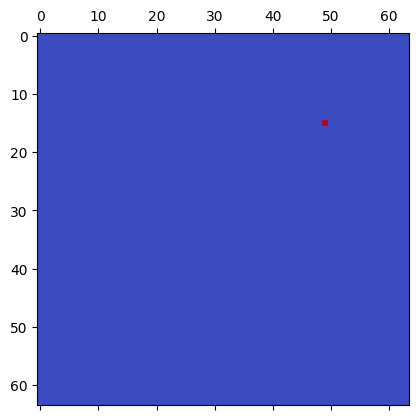

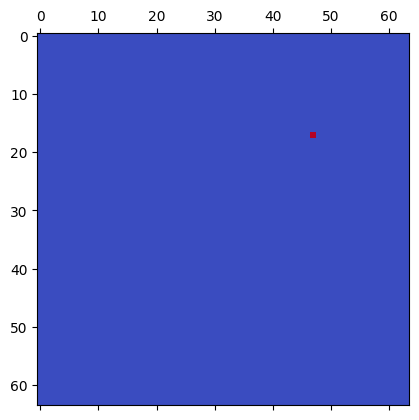

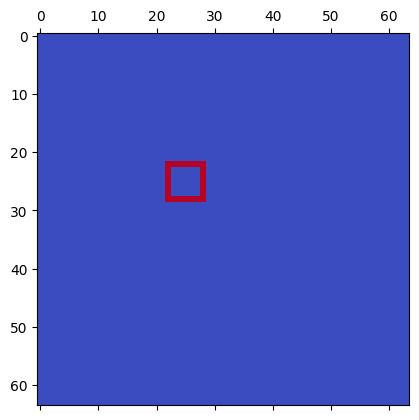

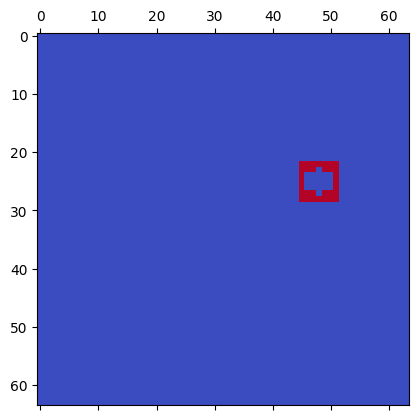

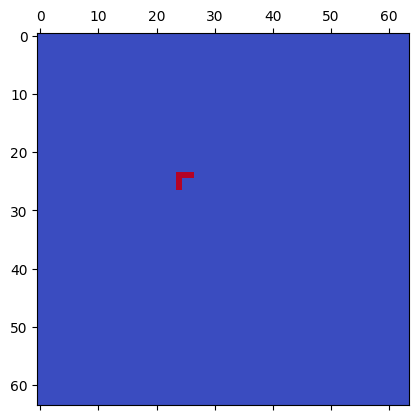

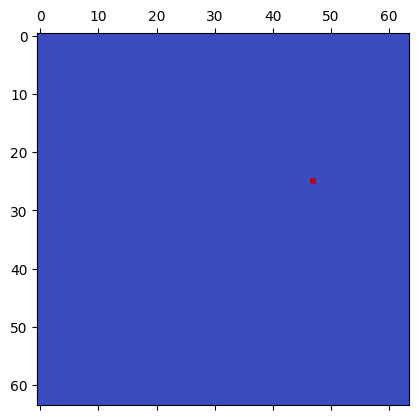

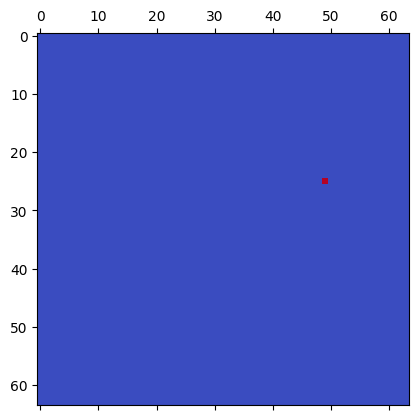

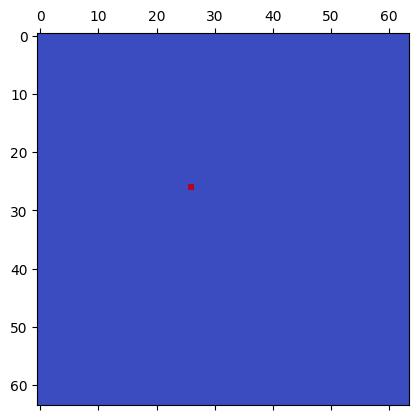

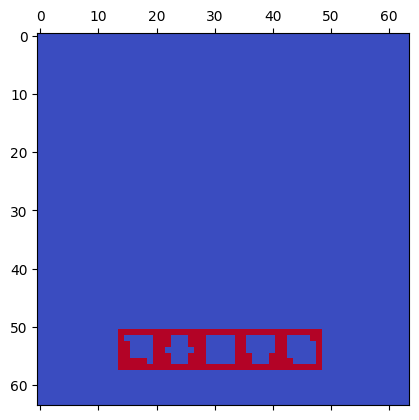

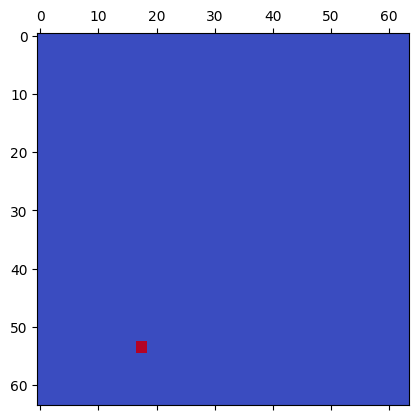

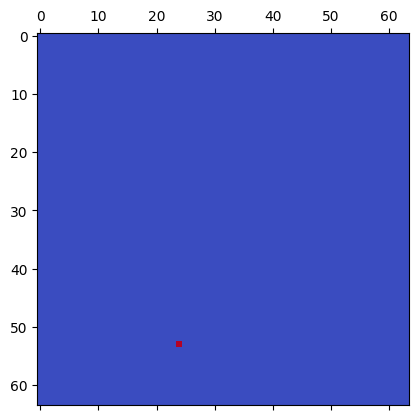

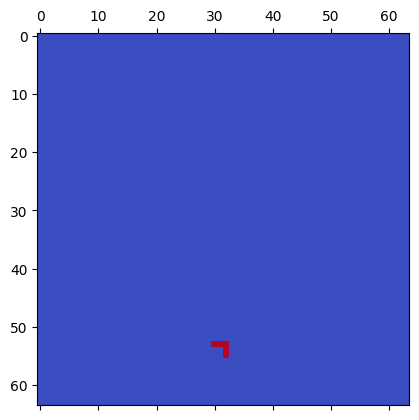

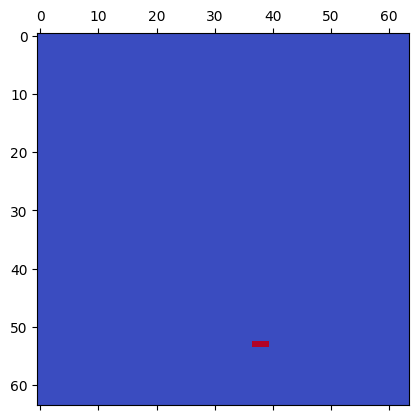

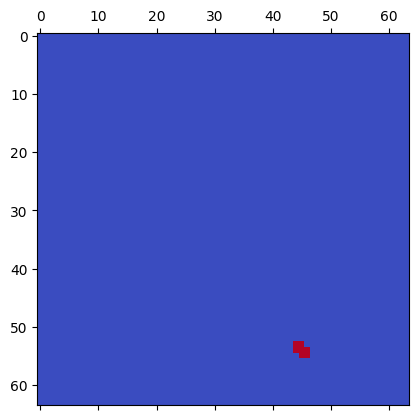

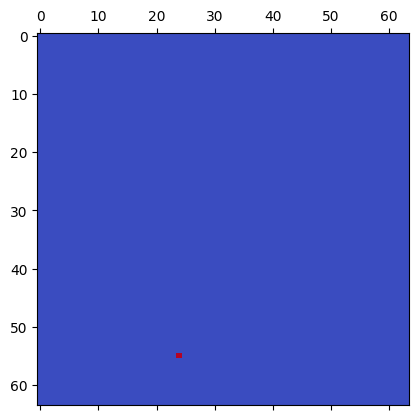

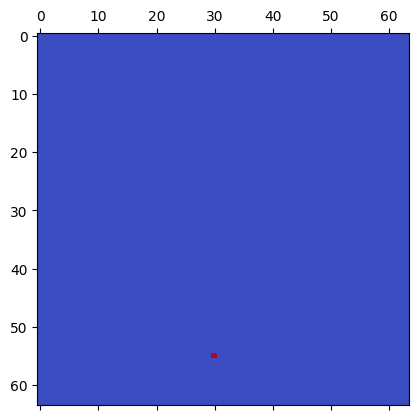

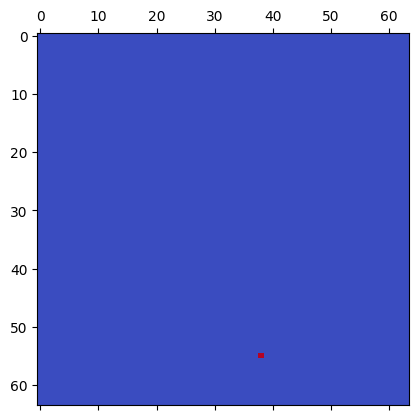

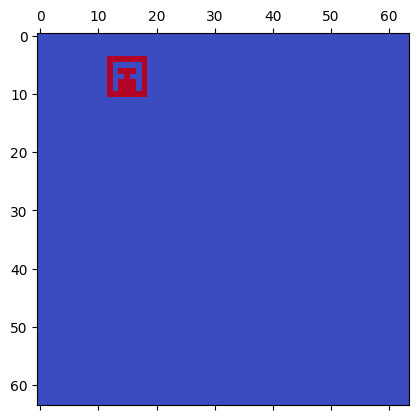

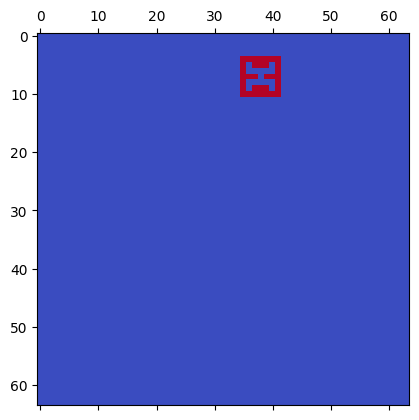

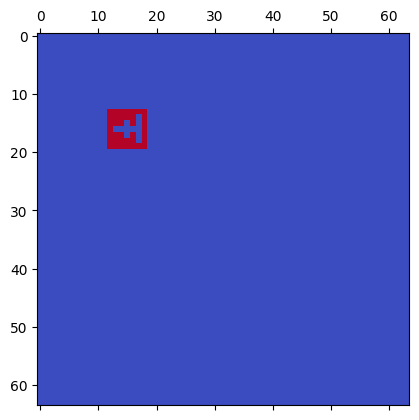

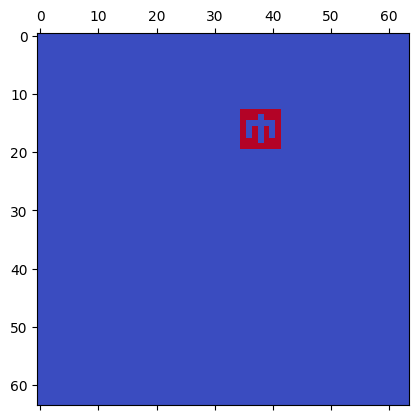

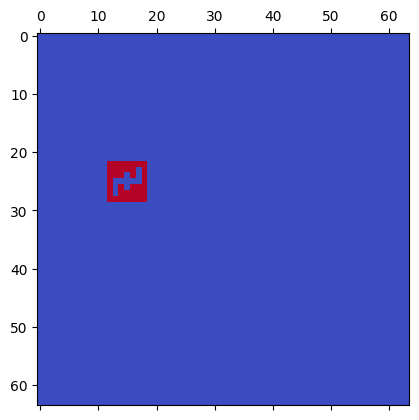

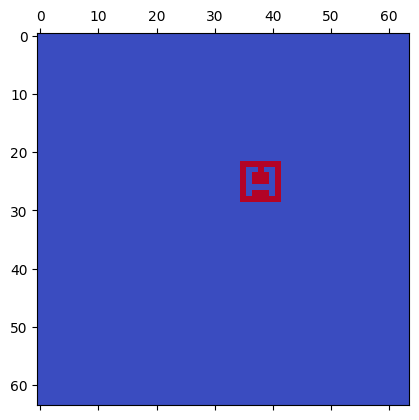

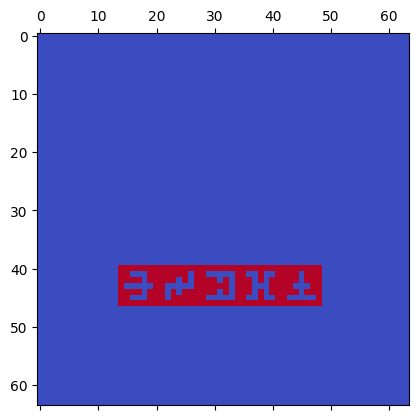

In [5]:
import numpy as np
from scipy.ndimage import label

def isolate_objects(matrix):
    """
    Isolates connected objects in a 2D numpy array.
    
    Parameters:
    matrix (np.ndarray): 2D array of uint8 with values 0..15
    
    Returns:
    np.ndarray: 3D array of shape (N, H, W) containing N isolated objects
    """
    # Define the 3x3 structuring element for 8-way connectivity (cross + diagonal)
    structure = np.ones((3, 3), dtype=int)
    
    isolated_objects = []
    
    # Find all unique colors present in the matrix
    unique_colors = np.unique(matrix)
    
    for color in unique_colors:
        # Create a binary mask for the current color
        color_mask = (matrix == color)
        
        # Label connected components for this specific color
        # labeled_array will contain 1 to num_features for distinct objects
        labeled_array, num_features = label(color_mask, structure=structure)
        
        # Isolate each object found for this color
        for obj_id in range(1, num_features + 1):
            # Start with a background of -1
            object_matrix = np.full(matrix.shape, -1, dtype=np.int16) 
            
            # Where this specific object exists, restore the original color value
            obj_mask = (labeled_array == obj_id)
            object_matrix[obj_mask] = color
            
            isolated_objects.append(object_matrix)
            
    # If no objects were found (empty matrix), return an empty 3D array
    if not isolated_objects:
        return np.empty((0, *matrix.shape), dtype=np.int16)
        
    # Stack the list of 2D matrices into a single 3D numpy array
    return np.stack(isolated_objects, axis=0)


def merge_objects(isolated_matrices):
    """
    Merges isolated object matrices back into larger components based on 
    4-way connectivity and matching colors.
    
    Parameters:
    isolated_matrices (np.ndarray): 3D array of shape (N, H, W) from isolate_objects
    
    Returns:
    np.ndarray: 3D array of shape (M, H, W) containing M merged objects (M <= N)
    """
    if isolated_matrices.shape[0] == 0:
        return isolated_matrices

    # Extract dimensions
    num_objects, height, width = isolated_matrices.shape
    
    # Define the 3x3 structuring element for 4-way connectivity (+ shape, no diagonals)
    structure = np.array([
        [0, 1, 0],
        [1, 1, 1],
        [0, 1, 0]
    ], dtype=int)
    
    merged_objects = []
    
    # Group the isolated matrices by their color to ensure we only merge matching colors.
    # We find the color of each matrix by looking for the maximum value (since background is -1)
    matrix_colors = np.array([matrix.max() for matrix in isolated_matrices])
    unique_colors = np.unique(matrix_colors)
    
    for color in unique_colors:
        if color < 0:
            continue  # Skip if a matrix somehow contains only -1
            
        # Select all isolated matrices that belong to this specific color
        color_indices = np.where(matrix_colors == color)[0]
        color_matrices = isolated_matrices[color_indices]
        
        # Combine all isolated pieces of this color into a single binary mask
        combined_mask = np.any(color_matrices >= 0, axis=0)
        
        # Label components using the + shape structure (4-way connectivity)
        # This will separate pieces that were previously only touching diagonally!
        labeled_array, num_features = label(combined_mask, structure=structure)
        
        # Reconstruct the merged matrices
        for obj_id in range(1, num_features + 1):
            merged_matrix = np.full((height, width), -1, dtype=np.int16)
            
            obj_mask = (labeled_array == obj_id)
            merged_matrix[obj_mask] = color
            
            merged_objects.append(merged_matrix)
            
    if not merged_objects:
        return np.empty((0, height, width), dtype=np.int16)
        
    return np.stack(merged_objects, axis=0)

objects = isolate_objects(data[sample_idx])
#objects = merge_objects(objects)

print(len(objects))
for o in objects:
    plt.matshow(o, cmap='coolwarm')